# 09 · Recomendación personalizada y explicable de barrios

Este notebook convierte el análisis multiobjetivo del notebook 08 en un recomendador utilizable.

El sistema permite:

- elegir un destino habitual;
- asignar distinta importancia al precio y al tiempo de desplazamiento;
- aplicar límites de precio, presupuesto orientativo, tiempo y fiabilidad;
- recalcular el frente de Pareto dentro de las alternativas compatibles;
- generar un ranking reproducible;
- explicar cada recomendación;
- comparar perfiles predefinidos;
- realizar una primera comprobación de sensibilidad;
- validar y exportar los resultados.

Los dos objetivos principales continúan siendo minimizar:

- `price_m2_for_recommender`;
- `commute_daily_minutes`.

> El presupuesto total es solo una conversión orientativa de `precio por m² × superficie de referencia`. No representa la tasación de una vivienda concreta.

## 1. Importaciones

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from pandas.api.types import is_bool_dtype

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 180)

## 2. Localización del proyecto y archivos

El notebook reutiliza `data/results/pareto_by_destination.csv`, generado en el notebook 08. De esta forma no se repite el cálculo general de Pareto.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la raíz del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PARETO_RESULTS_PATH = RESULTS_DIR / "pareto_by_destination.csv"

RECOMMENDATION_EXAMPLE_PATH = (
    RESULTS_DIR / "personalized_recommendation_example.csv"
)
FILTER_AUDIT_PATH = (
    RESULTS_DIR / "personalized_recommendation_filter_audit.csv"
)
PROFILE_DEFINITIONS_PATH = (
    RESULTS_DIR / "recommendation_profiles.csv"
)
PROFILE_COMPARISON_PATH = (
    RESULTS_DIR / "profile_recommendation_comparison.csv"
)
SENSITIVITY_EXAMPLE_PATH = (
    RESULTS_DIR / "recommendation_weight_sensitivity_example.csv"
)
SENSITIVITY_INTERVALS_PATH = (
    RESULTS_DIR / "recommendation_weight_sensitivity_intervals.csv"
)
VALIDATION_PATH = (
    RESULTS_DIR / "recommendation_engine_validation.csv"
)

USER_CASE_RECOMMENDATIONS_PATH = (
    RESULTS_DIR
    / "user_case_recommendations.csv"
)

USER_CASE_AUDIT_PATH = (
    RESULTS_DIR
    / "user_case_filter_audit.csv"
)

SENSITIVITY_ALL_DESTINATIONS_PATH = (
    RESULTS_DIR
    / "recommendation_weight_sensitivity_all_destinations.csv"
)

SENSITIVITY_INTERVALS_ALL_DESTINATIONS_PATH = (
    RESULTS_DIR
    / "recommendation_weight_sensitivity_intervals_all_destinations.csv"
)

SENSITIVITY_SUMMARY_PATH = (
    RESULTS_DIR
    / "recommendation_weight_sensitivity_summary.csv"
)

if not PARETO_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "No existe pareto_by_destination.csv. "
        "Ejecuta primero el notebook 08."
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Entrada:", PARETO_RESULTS_PATH)
print("Resultados:", RESULTS_DIR)

Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Entrada: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\results\pareto_by_destination.csv
Resultados: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\results


## 3. Carga y validación inicial

In [3]:
pareto_data = pd.read_csv(PARETO_RESULTS_PATH)

PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"

KEY_COLUMNS = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
]

REQUIRED_COLUMNS = KEY_COLUMNS + [
    PRICE_COLUMN,
    TIME_COLUMN,
    "is_pareto",
    "price_normalized",
    "time_normalized",
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in pareto_data.columns
]

if missing_columns:
    raise KeyError(
        "Faltan columnas necesarias: "
        f"{missing_columns}"
    )

duplicate_pairs = pareto_data.duplicated(
    ["zone_key", "destination_id"],
    keep=False,
)

if duplicate_pairs.any():
    display(
        pareto_data.loc[
            duplicate_pairs,
            KEY_COLUMNS,
        ]
    )
    raise ValueError(
        "Hay combinaciones barrio–destino duplicadas."
    )

print("Dimensiones:", pareto_data.shape)
print("Barrios:", pareto_data["zone_key"].nunique())
print("Destinos:", pareto_data["destination_id"].nunique())

display(pareto_data.head())

Dimensiones: (371, 145)
Barrios: 128
Destinos: 3


,zone_key,neighborhood_name,district_name,has_real_estate_data,price_estimate_available,coverage_status,total_listings,eligible_listings,excluded_listings,eligible_percentage,excluded_percentage,market_share_percentage,num_listings,price_eur_mean,price_eur_median,price_eur_q1,price_eur_q3,price_eur_iqr,price_eur_min,price_eur_max,price_m2_mean,price_m2_median,price_m2_q1,price_m2_q3,price_m2_iqr,price_m2_std,price_m2_relative_iqr_percentage,price_m2_median_ci_low,price_m2_median_ci_high,price_m2_median_ci_width,price_m2_median_ci_relative_width_percentage,price_m2_median_bootstrap_se,bootstrap_sample_size,bootstrap_iterations,bootstrap_confidence_level,bootstrap_status,area_m2_mean,area_m2_median,area_m2_q1,area_m2_q3,area_m2_iqr,area_m2_min,area_m2_max,rooms_mean,rooms_median,rooms_known_count,rooms_unknown_count,rooms_coverage_percentage,bathrooms_mean,bathrooms_median,bathrooms_known_count,bathrooms_unknown_count,bathrooms_coverage_percentage,elevator_ratio,elevator_percentage,elevator_known_count,elevator_unknown_count,elevator_coverage_percentage,exterior_ratio,exterior_percentage,exterior_known_count,exterior_unknown_count,exterior_coverage_percentage,sample_size_score,ci_precision_score,price_homogeneity_score,price_reliability_score,price_reliability_level,price_reliability_reason,market_scope,price_type,source_snapshot_date_status,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025,registered_price_available,registered_new_price_available,registered_used_price_available,reference_year,price_unit,price_statistic,housing_market_scope,source_publisher,source_origin,source_series_code,minimum_cases_to_publish_neighborhood,source_coverage_2025_percentage,kaggle_asking_price_available,kaggle_features_available,kaggle_sample_reliability_score,kaggle_sample_reliability_level,price_m2_for_recommender,price_m2_for_recommender_source,housing_data_availability_status,registered_minus_kaggle_eur_m2,registered_vs_kaggle_gap_percentage,registered_to_kaggle_price_ratio,destination_id,neighborhood_name_transit,district_name_transit,destination_name,service_date,evening_route_status,morning_route_status,morning_start_datetime,morning_end_datetime,morning_transit_modes,morning_routes_used,morning_agencies_used,morning_duration_minutes,morning_walk_time_minutes,morning_waiting_time_minutes,morning_walk_distance_meters,morning_number_of_transfers,evening_start_datetime,evening_end_datetime,evening_transit_modes,evening_routes_used,evening_agencies_used,evening_duration_minutes,evening_walk_time_minutes,evening_waiting_time_minutes,evening_walk_distance_meters,evening_number_of_transfers,commute_daily_minutes,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_transfers,no_route_scenarios,route_status,route_available,route_missing_reason,usable_for_pareto_knn,is_pareto,dominated_by_count,price_normalized,time_normalized,distance_to_ideal,pareto_balance_rank
0,MAD-021,Imperial,Arganzuela,True,True,available,73,71,2,97.26,2.74,0.64,71,552415.49,515000.0,377000.00,699950.0,322950.00,168800.0,1257000.0,5807.42,5588.24,4756.76,6536.43,1779.68,1358.43,31.85,5443.04,5808.82,365.79,6.55,107.93,71,2000,0.95,calculated,96.25,107.0,62.50,128.00,65.50,37.0,190.0,2.62,3.0,71,0,100.00,1.82,2.0,11,60,15.49,0.8571,85.71,70,1,98.59,0.8000,80.00,70,1,98.59,56.35,92.06,47.22,68.35,medium,La estimación presenta una estabilidad intermedia en comparación con el resto de barrios.,residential_sale,asking_price,unknown,5855.12,6010.51,5776.45,110.77,119.22,108.30,100,102.65,98.66,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,504020100060,15,97.7,True,True,68.35,medium,5855.12,registered_transactions_2025,official_price_and

In [4]:
def parse_boolean_series(
    series: pd.Series,
    column_name: str,
) -> pd.Series:
    if is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    true_values = {"true", "1", "yes", "y", "si", "sí"}
    false_values = {"false", "0", "no", "n"}
    valid_values = true_values | false_values

    invalid = (
        normalized.notna()
        & ~normalized.isin(valid_values)
    )

    if invalid.any():
        examples = sorted(
            normalized.loc[invalid]
            .dropna()
            .unique()
            .tolist()
        )[:10]

        raise ValueError(
            f"Valores no reconocidos en {column_name}: "
            f"{examples}"
        )

    return normalized.isin(true_values).fillna(False)


pareto_data["is_pareto"] = parse_boolean_series(
    pareto_data["is_pareto"],
    "is_pareto",
)

numeric_columns = [
    PRICE_COLUMN,
    TIME_COLUMN,
    "price_normalized",
    "time_normalized",
    "price_reliability_score",
    "dominated_by_count",
]

for column in numeric_columns:
    if column in pareto_data.columns:
        pareto_data[column] = pd.to_numeric(
            pareto_data[column],
            errors="coerce",
        )

invalid_objectives = pareto_data[
    pareto_data[[PRICE_COLUMN, TIME_COLUMN]]
    .isna()
    .any(axis=1)
    | (
        pareto_data[[PRICE_COLUMN, TIME_COLUMN]]
        <= 0
    ).any(axis=1)
]

if not invalid_objectives.empty:
    display(
        invalid_objectives[
            KEY_COLUMNS + [PRICE_COLUMN, TIME_COLUMN]
        ]
    )
    raise ValueError(
        "Existen precios o tiempos no válidos."
    )

normalized_valid = (
    pareto_data[
        ["price_normalized", "time_normalized"]
    ]
    .ge(-1e-9)
    .all()
    .all()
    and pareto_data[
        ["price_normalized", "time_normalized"]
    ]
    .le(1 + 1e-9)
    .all()
    .all()
)

if not normalized_valid:
    raise ValueError(
        "Las variables normalizadas no están en [0, 1]."
    )

print("Comprobaciones iniciales superadas.")

Comprobaciones iniciales superadas.


## 4. Destinos y perfiles predefinidos

Los perfiles sirven como casos reproducibles, pero el motor acepta cualquier combinación de pesos.

In [5]:
destination_catalog = (
    pareto_data[
        ["destination_id", "destination_name"]
    ]
    .drop_duplicates()
    .sort_values(
        ["destination_name", "destination_id"]
    )
    .reset_index(drop=True)
)

PREDEFINED_PROFILES = {
    "price_priority": {
        "profile_name": "Prioridad al precio",
        "price_weight": 0.75,
        "time_weight": 0.25,
    },
    "balanced": {
        "profile_name": "Perfil equilibrado",
        "price_weight": 0.50,
        "time_weight": 0.50,
    },
    "time_priority": {
        "profile_name": "Prioridad al tiempo",
        "price_weight": 0.25,
        "time_weight": 0.75,
    },
}

profile_definitions = pd.DataFrame(
    [
        {
            "profile_id": profile_id,
            **profile,
        }
        for profile_id, profile
        in PREDEFINED_PROFILES.items()
    ]
)

display(destination_catalog)
display(profile_definitions)

,destination_id,destination_name
0,DEST_002,Nuevos Ministerios
1,DEST_001,Puerta del Sol
2,DEST_003,UC3M Campus de Leganés


,profile_id,profile_name,price_weight,time_weight
0,price_priority,Prioridad al precio,0.75,0.25
1,balanced,Perfil equilibrado,0.50,0.50
2,time_priority,Prioridad al tiempo,0.25,0.75


## 5. Metodología del ranking

Primero se aplican las restricciones duras. Después se recalcula el frente de Pareto del conjunto compatible y se ordenan sus alternativas con:

\[
score_i =
w_{precio}\,precioNormalizado_i
+
w_{tiempo}\,tiempoNormalizado_i
\]

Cuanto menor es la puntuación, mejor encaja el barrio.

Las normalizaciones del notebook 08 se mantienen fijas para todo el destino. Así, añadir o retirar un filtro no modifica artificialmente la escala de comparación.

In [6]:
def pareto_mask_minimization(
    values: np.ndarray,
) -> np.ndarray:
    values = np.asarray(values, dtype=float)

    if values.ndim != 2:
        raise ValueError(
            "La matriz de objetivos debe ser bidimensional."
        )

    if np.isnan(values).any():
        raise ValueError(
            "No se puede calcular Pareto con NaN."
        )

    efficient = np.ones(len(values), dtype=bool)

    for index in range(len(values)):
        dominated = (
            np.all(values <= values[index], axis=1)
            & np.any(values < values[index], axis=1)
        )

        if dominated.any():
            efficient[index] = False

    return efficient


def normalize_weights(
    price_weight: float,
    time_weight: float,
) -> tuple[float, float]:
    weights = np.asarray(
        [price_weight, time_weight],
        dtype=float,
    )

    if not np.isfinite(weights).all():
        raise ValueError(
            "Los pesos deben ser finitos."
        )

    if (weights < 0).any():
        raise ValueError(
            "Los pesos no pueden ser negativos."
        )

    total = weights.sum()

    if np.isclose(total, 0):
        raise ValueError(
            "Al menos un peso debe ser positivo."
        )

    return (
        float(weights[0] / total),
        float(weights[1] / total),
    )


def positive_value_or_none(
    value: float | None,
    label: str,
) -> float | None:
    if value is None:
        return None

    value = float(value)

    if not np.isfinite(value) or value <= 0:
        raise ValueError(
            f"{label} debe ser positivo."
        )

    return value


def resolve_destination(
    data: pd.DataFrame,
    destination: str | int,
) -> tuple[object, str]:
    catalog = (
        data[
            ["destination_id", "destination_name"]
        ]
        .drop_duplicates()
        .copy()
    )

    destination_text = (
        str(destination)
        .strip()
        .casefold()
    )

    id_match = (
        catalog["destination_id"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(destination_text)
    )

    name_match = (
        catalog["destination_name"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(destination_text)
    )

    matches = catalog.loc[id_match | name_match]

    if matches.empty:
        available = ", ".join(
            catalog["destination_name"]
            .sort_values()
            .astype(str)
            .tolist()
        )

        raise KeyError(
            f"No existe el destino '{destination}'. "
            f"Disponibles: {available}"
        )

    if len(matches) > 1:
        raise ValueError(
            "El destino no es unívoco. "
            "Utiliza destination_id."
        )

    selected = matches.iloc[0]

    return (
        selected["destination_id"],
        str(selected["destination_name"]),
    )

## 6. Explicaciones automáticas

Las explicaciones se construyen a partir de los resultados observables y no presentan la recomendación como una decisión absoluta.

In [7]:
def relative_position_text(
    percentage: float,
    reference_name: str,
) -> str:
    if pd.isna(percentage):
        return (
            f"sin comparación disponible con "
            f"la mediana de {reference_name}"
        )

    if abs(percentage) < 0.05:
        return (
            f"prácticamente igual a la mediana "
            f"de {reference_name}"
        )

    direction = (
        "por encima"
        if percentage > 0
        else "por debajo"
    )

    return (
        f"un {abs(percentage):.1f} % "
        f"{direction} de la mediana "
        f"de {reference_name}"
    )


def build_recommendation_explanation(
    row: pd.Series,
) -> str:
    price_weight = float(
        row["price_weight"]
    )

    time_weight = float(
        row["time_weight"]
    )

    if price_weight >= time_weight + 0.15:
        priority_text = (
            "da más importancia al precio"
        )

    elif time_weight >= price_weight + 0.15:
        priority_text = (
            "da más importancia al tiempo "
            "de desplazamiento"
        )

    else:
        priority_text = (
            "busca un equilibrio parecido entre "
            "precio y desplazamiento"
        )

    original_pareto_text = ""

    if bool(
        row.get(
            "is_pareto",
            False,
        )
    ):
        original_pareto_text = (
            " También pertenecía al frente de Pareto "
            "general del destino."
        )

    reliability_text = ""

    if (
        "price_reliability_level"
        in row.index
        and pd.notna(
            row["price_reliability_level"]
        )
    ):
        reliability_text = (
            " El nivel de fiabilidad de la muestra "
            "inmobiliaria está clasificado como "
            f"{str(row['price_reliability_level']).lower()}."
        )

    elif (
        "price_reliability_score"
        in row.index
        and pd.notna(
            row["price_reliability_score"]
        )
    ):
        reliability_text = (
            " La puntuación de fiabilidad de la muestra "
            "inmobiliaria es de "
            f"{float(row['price_reliability_score']):.2f} "
            "sobre 100."
        )

    score_contribution_text = (
        " En la puntuación final, la contribución "
        "normalizada del precio es de "
        f"{float(row['price_score_contribution']):.3f} "
        "y la contribución del tiempo de desplazamiento "
        "es de "
        f"{float(row['time_score_contribution']):.3f}."
    )

    return (
        f"{row['neighborhood_name']} ocupa la posición "
        f"{int(row['recommendation_rank'])} para un perfil "
        f"que {priority_text}. Su precio de referencia es "
        f"{float(row[PRICE_COLUMN]):,.2f} €/m² y el "
        "desplazamiento diario estimado es de "
        f"{float(row[TIME_COLUMN]):.2f} minutos. "
        "El precio está "
        f"{relative_position_text(float(row['price_vs_destination_median_pct']), 'precio del destino')} "
        "y el tiempo está "
        f"{relative_position_text(float(row['time_vs_destination_median_pct']), 'tiempo del destino')}. "
        "La alternativa no está dominada dentro del "
        "conjunto compatible con las restricciones."
        f"{original_pareto_text}"
        f"{reliability_text}"
        f"{score_contribution_text}"
    )

## 7. Motor principal de recomendación

La fiabilidad se expresa en la escala original del proyecto, de 0 a 100. Se utiliza como filtro opcional y como desempate secundario; no sustituye al objetivo central precio–tiempo.

In [8]:
def recommend_neighborhoods(
    data: pd.DataFrame,
    destination: str | int,
    price_weight: float,
    time_weight: float,
    top_n: int = 5,
    max_price_m2: float | None = None,
    max_commute_daily_minutes: float | None = None,
    max_reference_budget_eur: float | None = None,
    reference_area_m2: float = 80.0,
    min_price_reliability_score: float | None = None,
    pareto_only: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Genera recomendaciones personalizadas para un destino.

    El proceso sigue estas etapas:

    1. valida y normaliza los pesos;
    2. selecciona las alternativas del destino;
    3. aplica las restricciones del usuario;
    4. recalcula el frente de Pareto compatible;
    5. calcula la puntuación personalizada;
    6. ordena y explica las recomendaciones.

    Devuelve:
        recommendations:
            Tabla con las alternativas recomendadas.

        audit:
            Tabla con el número de alternativas
            restantes y eliminadas en cada etapa.
    """

    if not isinstance(top_n, int) or top_n < 1:
        raise ValueError(
            "top_n debe ser un entero positivo."
        )

    price_weight, time_weight = normalize_weights(
        price_weight,
        time_weight,
    )

    max_price_m2 = positive_value_or_none(
        max_price_m2,
        "max_price_m2",
    )

    max_commute_daily_minutes = (
        positive_value_or_none(
            max_commute_daily_minutes,
            "max_commute_daily_minutes",
        )
    )

    max_reference_budget_eur = (
        positive_value_or_none(
            max_reference_budget_eur,
            "max_reference_budget_eur",
        )
    )

    reference_area_m2 = positive_value_or_none(
        reference_area_m2,
        "reference_area_m2",
    )

    if min_price_reliability_score is not None:
        min_price_reliability_score = float(
            min_price_reliability_score
        )

        if not (
            0
            <= min_price_reliability_score
            <= 100
        ):
            raise ValueError(
                "La fiabilidad mínima debe estar "
                "entre 0 y 100."
            )

    destination_id, destination_name = (
        resolve_destination(
            data,
            destination,
        )
    )

    destination_data = (
        data.loc[
            data["destination_id"]
            .astype(str)
            .eq(str(destination_id))
        ]
        .copy()
        .reset_index(drop=True)
    )

    if destination_data.empty:
        raise ValueError(
            "El destino seleccionado no contiene "
            "alternativas disponibles."
        )

    destination_data[
        "reference_price_eur"
    ] = (
        destination_data[PRICE_COLUMN]
        * reference_area_m2
    )

    audit_rows = [
        {
            "stage": "Destino seleccionado",
            "remaining_alternatives": len(
                destination_data
            ),
            "removed_alternatives": 0,
        }
    ]

    def build_audit_table() -> pd.DataFrame:
        """
        Construye la auditoría completa.

        Esta función garantiza que destination_id y
        destination_name aparezcan incluso cuando
        las restricciones dejan cero alternativas.
        """

        audit = pd.DataFrame(
            audit_rows
        )

        audit["destination_id"] = (
            destination_id
        )

        audit["destination_name"] = (
            destination_name
        )

        return audit

    eligible = destination_data.copy()

    def apply_filter(
        mask: pd.Series,
        stage: str,
    ) -> None:
        """
        Aplica un filtro y registra cuántas
        alternativas se eliminan.
        """

        nonlocal eligible

        previous_count = len(
            eligible
        )

        eligible = (
            eligible.loc[mask]
            .copy()
        )

        audit_rows.append(
            {
                "stage": stage,
                "remaining_alternatives": len(
                    eligible
                ),
                "removed_alternatives": (
                    previous_count
                    - len(eligible)
                ),
            }
        )

    if max_price_m2 is not None:
        apply_filter(
            eligible[PRICE_COLUMN]
            <= max_price_m2,
            "Precio máximo por m²",
        )

    if max_reference_budget_eur is not None:
        apply_filter(
            eligible["reference_price_eur"]
            <= max_reference_budget_eur,
            "Presupuesto orientativo máximo",
        )

    if max_commute_daily_minutes is not None:
        apply_filter(
            eligible[TIME_COLUMN]
            <= max_commute_daily_minutes,
            "Tiempo diario máximo",
        )

    if min_price_reliability_score is not None:
        if (
            "price_reliability_score"
            not in eligible.columns
        ):
            raise KeyError(
                "No existe la columna "
                "price_reliability_score."
            )

        apply_filter(
            (
                eligible[
                    "price_reliability_score"
                ].notna()
            )
            & (
                eligible[
                    "price_reliability_score"
                ]
                >= min_price_reliability_score
            ),
            "Fiabilidad mínima",
        )

    # Puede ocurrir que ninguna alternativa
    # cumpla las restricciones del usuario.
    if eligible.empty:
        return (
            eligible,
            build_audit_table(),
        )

    eligible[
        "is_pareto_eligible"
    ] = pareto_mask_minimization(
        eligible[
            [
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        ].to_numpy(
            dtype=float
        )
    )

    if pareto_only:
        apply_filter(
            eligible[
                "is_pareto_eligible"
            ],
            "Frente de Pareto compatible",
        )

    # Se vuelve a comprobar por seguridad después
    # de aplicar el filtro de Pareto.
    if eligible.empty:
        return (
            eligible,
            build_audit_table(),
        )

    eligible["price_weight"] = (
        price_weight
    )

    eligible["time_weight"] = (
        time_weight
    )

    eligible[
        "price_score_contribution"
    ] = (
        price_weight
        * eligible[
            "price_normalized"
        ]
    )

    eligible[
        "time_score_contribution"
    ] = (
        time_weight
        * eligible[
            "time_normalized"
        ]
    )

    eligible[
        "preference_score"
    ] = (
        eligible[
            "price_score_contribution"
        ]
        + eligible[
            "time_score_contribution"
        ]
    )

    eligible[
        "reference_area_m2"
    ] = (
        reference_area_m2
    )

    destination_price_median = (
        destination_data[
            PRICE_COLUMN
        ].median()
    )

    destination_time_median = (
        destination_data[
            TIME_COLUMN
        ].median()
    )

    eligible[
        "price_vs_destination_median_pct"
    ] = (
        (
            eligible[PRICE_COLUMN]
            / destination_price_median
        )
        - 1
    ) * 100

    eligible[
        "time_vs_destination_median_pct"
    ] = (
        (
            eligible[TIME_COLUMN]
            / destination_time_median
        )
        - 1
    ) * 100

    eligible[
        "extra_price_vs_cheapest_eur_m2"
    ] = (
        eligible[PRICE_COLUMN]
        - eligible[
            PRICE_COLUMN
        ].min()
    )

    eligible[
        "extra_time_vs_fastest_minutes"
    ] = (
        eligible[TIME_COLUMN]
        - eligible[
            TIME_COLUMN
        ].min()
    )

    # Las alternativas que pertenecían al frente
    # general se priorizan como criterio secundario.
    eligible[
        "_original_pareto_sort"
    ] = (
        ~eligible["is_pareto"]
    ).astype(int)

    sort_columns = [
        "preference_score",
        "_original_pareto_sort",
    ]

    ascending_order = [
        True,
        True,
    ]

    # La fiabilidad no forma parte de la puntuación
    # principal. Solo se usa como desempate.
    if (
        "price_reliability_score"
        in eligible.columns
    ):
        sort_columns.append(
            "price_reliability_score"
        )

        ascending_order.append(
            False
        )

    sort_columns.extend(
        [
            PRICE_COLUMN,
            TIME_COLUMN,
            "zone_key",
        ]
    )

    ascending_order.extend(
        [
            True,
            True,
            True,
        ]
    )

    recommendations = (
        eligible
        .sort_values(
            sort_columns,
            ascending=ascending_order,
            na_position="last",
        )
        .head(top_n)
        .copy()
        .reset_index(drop=True)
    )

    recommendations[
        "recommendation_rank"
    ] = np.arange(
        1,
        len(recommendations) + 1,
    )

    recommendations[
        "recommendation_explanation"
    ] = recommendations.apply(
        build_recommendation_explanation,
        axis=1,
    )

    recommendations.drop(
        columns=[
            "_original_pareto_sort",
        ],
        inplace=True,
        errors="ignore",
    )

    return (
        recommendations,
        build_audit_table(),
    )

## 8. Caso personalizado

Esta es la celda que debe modificarse para probar distintos usuarios. Un valor `None` desactiva la restricción correspondiente.

In [9]:
EXAMPLE_DESTINATION = (
    destination_catalog.iloc[0]["destination_id"]
)

EXAMPLE_PRICE_WEIGHT = 0.50
EXAMPLE_TIME_WEIGHT = 0.50
EXAMPLE_TOP_N = 5

EXAMPLE_MAX_PRICE_M2 = None
EXAMPLE_MAX_COMMUTE_DAILY_MINUTES = None
EXAMPLE_MAX_REFERENCE_BUDGET_EUR = None

EXAMPLE_REFERENCE_AREA_M2 = 80.0

# Escala 0-100. None desactiva el filtro.
EXAMPLE_MIN_PRICE_RELIABILITY_SCORE = None

EXAMPLE_PARETO_ONLY = True

In [10]:
example_recommendations, example_audit = (
    recommend_neighborhoods(
        data=pareto_data,
        destination=EXAMPLE_DESTINATION,
        price_weight=EXAMPLE_PRICE_WEIGHT,
        time_weight=EXAMPLE_TIME_WEIGHT,
        top_n=EXAMPLE_TOP_N,
        max_price_m2=EXAMPLE_MAX_PRICE_M2,
        max_commute_daily_minutes=(
            EXAMPLE_MAX_COMMUTE_DAILY_MINUTES
        ),
        max_reference_budget_eur=(
            EXAMPLE_MAX_REFERENCE_BUDGET_EUR
        ),
        reference_area_m2=(
            EXAMPLE_REFERENCE_AREA_M2
        ),
        min_price_reliability_score=(
            EXAMPLE_MIN_PRICE_RELIABILITY_SCORE
        ),
        pareto_only=EXAMPLE_PARETO_ONLY,
    )
)

display(example_audit)

if example_recommendations.empty:
    display(
        Markdown(
            """
### No se han encontrado alternativas

Ningún barrio cumple simultáneamente las restricciones.
Conviene relajar alguno de los límites.
"""
        )
    )
else:
    display_columns = [
        "recommendation_rank",
        "zone_key",
        "neighborhood_name",
        "district_name",
        PRICE_COLUMN,
        TIME_COLUMN,
        "reference_area_m2",
        "reference_price_eur",
        "price_weight",
        "time_weight",
        "price_score_contribution",
        "time_score_contribution",
        "preference_score",
        "is_pareto",
        "is_pareto_eligible",
        "price_vs_destination_median_pct",
        "time_vs_destination_median_pct",
        "extra_price_vs_cheapest_eur_m2",
        "extra_time_vs_fastest_minutes",
    ]

    for optional_column in [
        "price_reliability_score",
        "price_reliability_level",
        "price_m2_for_recommender_source",
    ]:
        if optional_column in example_recommendations.columns:
            display_columns.append(optional_column)

    display(
        example_recommendations[display_columns]
    )

,stage,remaining_alternatives,removed_alternatives,destination_id,destination_name
0,Destino seleccionado,124,0,DEST_002,Nuevos Ministerios
1,Frente de Pareto compatible,10,114,DEST_002,Nuevos Ministerios


,recommendation_rank,zone_key,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,reference_area_m2,reference_price_eur,price_weight,time_weight,price_score_contribution,time_score_contribution,preference_score,is_pareto,is_pareto_eligible,price_vs_destination_median_pct,time_vs_destination_median_pct,extra_price_vs_cheapest_eur_m2,extra_time_vs_fastest_minutes,price_reliability_score,price_reliability_level,price_m2_for_recommender_source
0,1,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,80.0,417913.6,0.5,0.5,0.135841,0.010470,0.146311,True,True,9.105111,-58.774834,3314.32,4.833333,78.37,high,registered_transactions_2025
1,2,MAD-206,Rejas,San Blas - Canillejas,3580.16,82.266667,80.0,286412.8,0.5,0.5,0.068470,0.080800,0.149270,True,True,-25.225931,-31.898455,1670.56,37.300000,49.60,low,registered_transactions_2025
2,3,MAD-207,Canillejas,San Blas - Canillejas,3409.64,86.016667,80.0,272771.2,0.5,0.5,0.061481,0.088923,0.150404,True,True,-28.787357,-28.794150,1500.04,41.050000,51.94,medium,registered_transactions_2025
3,4,MAD-064,Almenara,Tetuán,4987.49,58.550000,80.0,398999.2,0.5,0.5,0.126151,0.029425,0.155576,True,True,4.167110,-51.531457,3077.89,13.583333,23.12,low,registered_transactions_2025
4,5,MAD-066,Berruguete,Tetuán,4789.99,63.350000,80.0,383199.2,0.5,0.5,0.118056,0.039822,0.157879,True,True,0.042189,-47.557947,2880.39,18.383333,69.68,medium,registered_transactions_2025


In [11]:
if not example_recommendations.empty:
    for _, row in (
        example_recommendations
        .sort_values("recommendation_rank")
        .iterrows()
    ):
        display(
            Markdown(
                f"""
### {int(row['recommendation_rank'])}. {row['neighborhood_name']}

{row['recommendation_explanation']}
"""
            )
        )


### 1. Bellas Vistas

Bellas Vistas ocupa la posición 1 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 5,223.92 €/m² y el desplazamiento diario estimado es de 49.80 minutos. El precio está un 9.1 % por encima de la mediana de precio del destino y el tiempo está un 58.8 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como high. En la puntuación final, la contribución normalizada del precio es de 0.136 y la contribución del tiempo de desplazamiento es de 0.010.



### 2. Rejas

Rejas ocupa la posición 2 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 3,580.16 €/m² y el desplazamiento diario estimado es de 82.27 minutos. El precio está un 25.2 % por debajo de la mediana de precio del destino y el tiempo está un 31.9 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como low. En la puntuación final, la contribución normalizada del precio es de 0.068 y la contribución del tiempo de desplazamiento es de 0.081.



### 3. Canillejas

Canillejas ocupa la posición 3 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 3,409.64 €/m² y el desplazamiento diario estimado es de 86.02 minutos. El precio está un 28.8 % por debajo de la mediana de precio del destino y el tiempo está un 28.8 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como medium. En la puntuación final, la contribución normalizada del precio es de 0.061 y la contribución del tiempo de desplazamiento es de 0.089.



### 4. Almenara

Almenara ocupa la posición 4 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 4,987.49 €/m² y el desplazamiento diario estimado es de 58.55 minutos. El precio está un 4.2 % por encima de la mediana de precio del destino y el tiempo está un 51.5 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como low. En la puntuación final, la contribución normalizada del precio es de 0.126 y la contribución del tiempo de desplazamiento es de 0.029.



### 5. Berruguete

Berruguete ocupa la posición 5 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 4,789.99 €/m² y el desplazamiento diario estimado es de 63.35 minutos. El precio está prácticamente igual a la mediana de precio del destino y el tiempo está un 47.6 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como medium. En la puntuación final, la contribución normalizada del precio es de 0.118 y la contribución del tiempo de desplazamiento es de 0.040.


## 9. Visualización

Las mejores posiciones se encuentran hacia la esquina inferior izquierda: menor precio y menor tiempo.

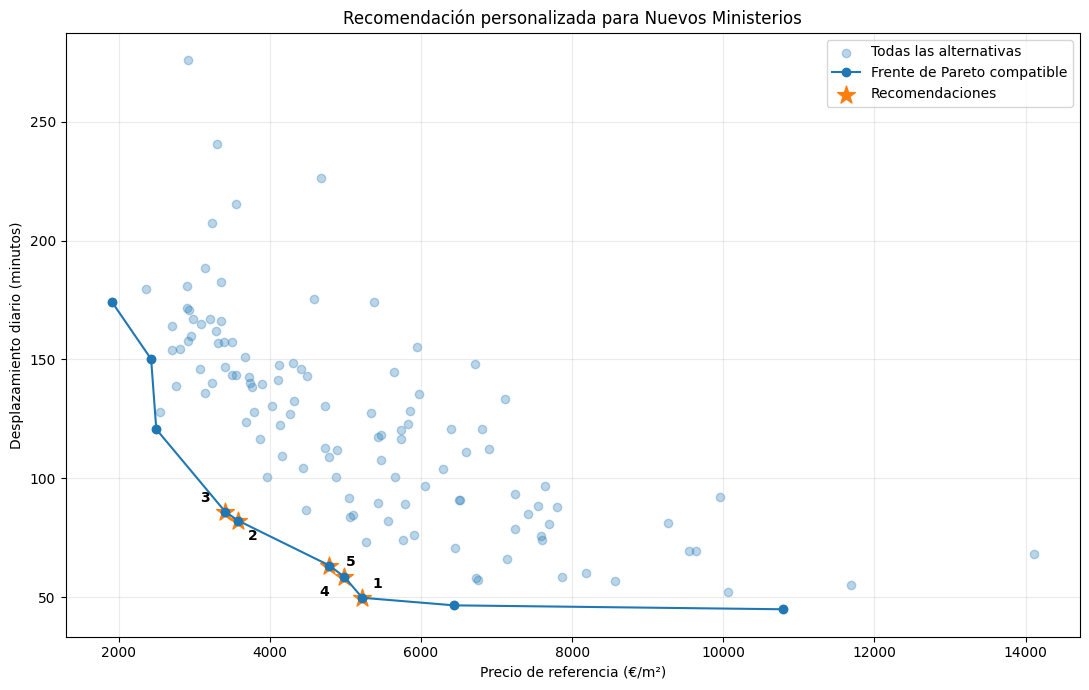

In [12]:
def plot_personalized_recommendation(
    data: pd.DataFrame,
    recommendations: pd.DataFrame,
    destination: str | int,
    max_price_m2: float | None = None,
    max_commute_daily_minutes: float | None = None,
    max_reference_budget_eur: float | None = None,
    reference_area_m2: float = 80.0,
    min_price_reliability_score: float | None = None,
) -> None:
    """
    Representa gráficamente las alternativas disponibles,
    las compatibles con las restricciones, el frente de
    Pareto compatible y las recomendaciones personalizadas.
    """

    destination_id, destination_name = (
        resolve_destination(
            data,
            destination,
        )
    )

    destination_data = (
        data.loc[
            data["destination_id"]
            .astype(str)
            .eq(str(destination_id))
        ]
        .copy()
    )

    destination_data[
        "reference_price_eur"
    ] = (
        destination_data[PRICE_COLUMN]
        * reference_area_m2
    )

    compatible = destination_data.copy()

    # Aplicación de las mismas restricciones
    # utilizadas por el recomendador.
    if max_price_m2 is not None:
        compatible = compatible.loc[
            compatible[PRICE_COLUMN]
            <= max_price_m2
        ]

    if max_reference_budget_eur is not None:
        compatible = compatible.loc[
            compatible["reference_price_eur"]
            <= max_reference_budget_eur
        ]

    if max_commute_daily_minutes is not None:
        compatible = compatible.loc[
            compatible[TIME_COLUMN]
            <= max_commute_daily_minutes
        ]

    if min_price_reliability_score is not None:
        if (
            "price_reliability_score"
            not in compatible.columns
        ):
            raise KeyError(
                "No existe la columna "
                "price_reliability_score."
            )

        compatible = compatible.loc[
            compatible[
                "price_reliability_score"
            ].notna()
            & (
                compatible[
                    "price_reliability_score"
                ]
                >= min_price_reliability_score
            )
        ]

    # Se comprueba si el usuario ha indicado
    # alguna restricción.
    has_active_constraints = any(
        value is not None
        for value in [
            max_price_m2,
            max_commute_daily_minutes,
            max_reference_budget_eur,
            min_price_reliability_score,
        ]
    )

    # Cálculo del frente de Pareto dentro del
    # conjunto compatible.
    if compatible.empty:
        compatible_front = (
            compatible.copy()
        )

    else:
        compatible[
            "is_pareto_eligible"
        ] = pareto_mask_minimization(
            compatible[
                [
                    PRICE_COLUMN,
                    TIME_COLUMN,
                ]
            ].to_numpy(
                dtype=float
            )
        )

        compatible_front = (
            compatible.loc[
                compatible[
                    "is_pareto_eligible"
                ]
            ]
            .sort_values(
                PRICE_COLUMN
            )
        )

    plt.figure(
        figsize=(11, 7)
    )

    # Todas las alternativas disponibles
    # para el destino.
    plt.scatter(
        destination_data[
            PRICE_COLUMN
        ],
        destination_data[
            TIME_COLUMN
        ],
        alpha=0.30,
        label="Todas las alternativas",
    )

    # Solo se muestran por separado las alternativas
    # compatibles cuando existen restricciones activas.
    # Así se evita representar dos veces el mismo conjunto.
    if (
        has_active_constraints
        and not compatible.empty
    ):
        plt.scatter(
            compatible[
                PRICE_COLUMN
            ],
            compatible[
                TIME_COLUMN
            ],
            alpha=0.55,
            label="Alternativas compatibles",
        )

    # Frente de Pareto del conjunto compatible.
    if not compatible_front.empty:
        plt.plot(
            compatible_front[
                PRICE_COLUMN
            ],
            compatible_front[
                TIME_COLUMN
            ],
            marker="o",
            label=(
                "Frente de Pareto compatible"
            ),
        )

    # Recomendaciones finales.
    if not recommendations.empty:
        plt.scatter(
            recommendations[
                PRICE_COLUMN
            ],
            recommendations[
                TIME_COLUMN
            ],
            marker="*",
            s=180,
            label="Recomendaciones",
        )

        # Posiciones diferentes para evitar que
        # las etiquetas del ranking se solapen.
        label_offsets = [
            (7, 7),
            (7, -14),
            (-18, 7),
            (-18, -14),
            (12, 0),
        ]

        for position, (_, row) in enumerate(
            recommendations.iterrows()
        ):
            offset = label_offsets[
                position
                % len(label_offsets)
            ]

            plt.annotate(
                str(
                    int(
                        row[
                            "recommendation_rank"
                        ]
                    )
                ),
                (
                    row[PRICE_COLUMN],
                    row[TIME_COLUMN],
                ),
                xytext=offset,
                textcoords="offset points",
                fontweight="bold",
            )

    plt.xlabel(
        "Precio de referencia (€/m²)"
    )

    plt.ylabel(
        "Desplazamiento diario (minutos)"
    )

    plt.title(
        "Recomendación personalizada "
        f"para {destination_name}"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


plot_personalized_recommendation(
    data=pareto_data,
    recommendations=(
        example_recommendations
    ),
    destination=(
        EXAMPLE_DESTINATION
    ),
    max_price_m2=(
        EXAMPLE_MAX_PRICE_M2
    ),
    max_commute_daily_minutes=(
        EXAMPLE_MAX_COMMUTE_DAILY_MINUTES
    ),
    max_reference_budget_eur=(
        EXAMPLE_MAX_REFERENCE_BUDGET_EUR
    ),
    reference_area_m2=(
        EXAMPLE_REFERENCE_AREA_M2
    ),
    min_price_reliability_score=(
        EXAMPLE_MIN_PRICE_RELIABILITY_SCORE
    ),
)

## 9.1. Casos de uso con restricciones

Para comprobar el funcionamiento del recomendador en situaciones más realistas, se definen tres casos de uso. Los perfiles y restricciones son ejemplos ilustrativos y no proceden de una encuesta de preferencias.

Los casos representan:

1. un estudiante que se desplaza a la UC3M y concede mayor importancia al precio;
2. un profesional que trabaja en Nuevos Ministerios y prioriza reducir el desplazamiento;
3. una persona con un perfil equilibrado cuyo destino habitual es Puerta del Sol.

El presupuesto se interpreta como una referencia territorial para una vivienda de 80 m² y no como el precio exacto de una vivienda concreta.

In [13]:
USER_CASES = {
    "student_uc3m": {
        "case_name": (
            "Estudiante con destino UC3M"
        ),
        "destination": "DEST_003",
        "price_weight": 0.75,
        "time_weight": 0.25,
        "max_reference_budget_eur": 300_000,
        "max_commute_daily_minutes": 150,
        "reference_area_m2": 80,
        "min_price_reliability_score": 30,
    },
    "professional_nuevos_ministerios": {
        "case_name": (
            "Profesional en Nuevos Ministerios"
        ),
        "destination": "DEST_002",
        "price_weight": 0.25,
        "time_weight": 0.75,
        "max_reference_budget_eur": 500_000,
        "max_commute_daily_minutes": 90,
        "reference_area_m2": 80,
        "min_price_reliability_score": 50,
    },
    "balanced_sol": {
        "case_name": (
            "Perfil equilibrado con destino Sol"
        ),
        "destination": "DEST_001",
        "price_weight": 0.50,
        "time_weight": 0.50,
        "max_reference_budget_eur": 400_000,
        "max_commute_daily_minutes": 100,
        "reference_area_m2": 80,
        "min_price_reliability_score": 40,
    },
}

In [14]:
case_recommendation_frames = []
case_audit_frames = []

for case_id, case_config in USER_CASES.items():
    recommendations, audit = (
        recommend_neighborhoods(
            data=pareto_data,
            destination=(
                case_config["destination"]
            ),
            price_weight=(
                case_config["price_weight"]
            ),
            time_weight=(
                case_config["time_weight"]
            ),
            top_n=5,
            max_reference_budget_eur=(
                case_config[
                    "max_reference_budget_eur"
                ]
            ),
            max_commute_daily_minutes=(
                case_config[
                    "max_commute_daily_minutes"
                ]
            ),
            reference_area_m2=(
                case_config["reference_area_m2"]
            ),
            min_price_reliability_score=(
                case_config[
                    "min_price_reliability_score"
                ]
            ),
            pareto_only=True,
        )
    )

    audit.insert(
        0,
        "case_id",
        case_id,
    )

    audit.insert(
        1,
        "case_name",
        case_config["case_name"],
    )

    case_audit_frames.append(audit)

    if not recommendations.empty:
        recommendations.insert(
            0,
            "case_id",
            case_id,
        )

        recommendations.insert(
            1,
            "case_name",
            case_config["case_name"],
        )

        case_recommendation_frames.append(
            recommendations
        )


case_audits = pd.concat(
    case_audit_frames,
    ignore_index=True,
)

case_recommendations = (
    pd.concat(
        case_recommendation_frames,
        ignore_index=True,
    )
    if case_recommendation_frames
    else pd.DataFrame()
)

display(case_audits)

,case_id,case_name,stage,remaining_alternatives,removed_alternatives,destination_id,destination_name
0,student_uc3m,Estudiante con destino UC3M,Destino seleccionado,128,0,DEST_003,UC3M Campus de Leganés
1,student_uc3m,Estudiante con destino UC3M,Presupuesto orientativo máximo,40,88,DEST_003,UC3M Campus de Leganés
2,student_uc3m,Estudiante con destino UC3M,Tiempo diario máximo,21,19,DEST_003,UC3M Campus de Leganés
3,student_uc3m,Estudiante con destino UC3M,Fiabilidad mínima,14,7,DEST_003,UC3M Campus de Leganés
4,student_uc3m,Estudiante con destino UC3M,Frente de Pareto compatible,4,10,DEST_003,UC3M Campus de Leganés
5,professional_nuevos_ministerios,Profesional en Nuevos Ministerios,Destino seleccionado,124,0,DEST_002,Nuevos Ministerios
6,professional_nuevos_ministerios,Profesional en Nuevos Ministerios,Presupuesto orientativo máximo,90,34,DEST_002,Nuevos Ministerios
7,professional_nuevos_ministerios,Profesional en Nuevos Ministerios,Tiempo diario máximo,14,76,DEST_002,Nuevos Ministerios
8,professional_nuevos_ministerios,Profesional en Nuevos Ministerios,Fiabilidad mínima,6,8,DEST_002,Nuevos Ministerios
9,professional_nuevos_ministerios,Profesional en Nuevos Ministerios,Frente de Pareto compatible,3,3,DEST_002,Nuevos Ministerios


In [15]:
if case_recommendations.empty:
    display(
        Markdown(
            """
### No hay recomendaciones

Ninguno de los casos definidos ha producido
alternativas compatibles.
"""
        )
    )
else:
    case_display_columns = [
        "case_name",
        "destination_name",
        "recommendation_rank",
        "neighborhood_name",
        "district_name",
        PRICE_COLUMN,
        TIME_COLUMN,
        "reference_price_eur",
        "price_reliability_score",
        "price_score_contribution",
        "time_score_contribution",
        "preference_score",
    ]

    display(
        case_recommendations[
            case_display_columns
        ].sort_values(
            [
                "case_name",
                "recommendation_rank",
            ]
        )
    )

,case_name,destination_name,recommendation_rank,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,reference_price_eur,price_reliability_score,price_score_contribution,time_score_contribution,preference_score
0,Estudiante con destino UC3M,UC3M Campus de Leganés,1,San Cristóbal,Villaverde,1909.60,136.333333,152768.0,36.67,0.000000,0.076547,0.076547
1,Estudiante con destino UC3M,UC3M Campus de Leganés,2,Puerta Bonita,Carabanchel,2905.06,77.750000,232404.8,51.59,0.061200,0.023613,0.084813
2,Estudiante con destino UC3M,UC3M Campus de Leganés,3,Buenavista,Carabanchel,3291.57,51.616667,263325.6,56.03,0.084963,0.000000,0.084963
3,Estudiante con destino UC3M,UC3M Campus de Leganés,4,Vista Alegre,Carabanchel,3213.22,74.283333,257057.6,60.56,0.080146,0.020481,0.100626
7,Perfil equilibrado con destino Sol,Puerta del Sol,1,Puerta del Ángel,Latina,4033.30,65.133333,322664.0,50.63,0.087042,0.023297,0.110339
8,Perfil equilibrado con destino Sol,Puerta del Sol,2,Moscardó,Usera,3739.18,79.500000,299134.4,40.95,0.074988,0.061476,0.136463
9,Perfil equilibrado con destino Sol,Puerta del Sol,3,Opañel,Carabanchel,3500.89,83.750000,280071.2,66.55,0.065221,0.072770,0.137991
4,Profesional en Nuevos Ministerios,Nuevos Ministerios,1,Bellas Vistas,Tetuán,5223.92,49.800000,417913.6,78.37,0.067921,0.015705,0.083626
5,Profesional en Nuevos Ministerios,Nuevos Ministerios,2,Berruguete,Tetuán,4789.99,63.350000,383199.2,69.68,0.059028,0.059734,0.118762
6,Profesional en Nuevos Ministerios,Nuevos Ministerios,3,Canillejas,San Blas - Canillejas,3409.64,86.016667,272771.2,51.94,0.030740,0.133385,0.164126


In [16]:
for case_id, case_data in (
    case_recommendations
    .groupby("case_id")
):
    case_name = (
        case_data["case_name"].iloc[0]
    )

    display(
        Markdown(
            f"""
## {case_name}
"""
        )
    )

    for _, row in (
        case_data
        .sort_values("recommendation_rank")
        .iterrows()
    ):
        display(
            Markdown(
                f"""
### {int(row['recommendation_rank'])}. {row['neighborhood_name']}

{row['recommendation_explanation']}
"""
            )
        )


## Perfil equilibrado con destino Sol



### 1. Puerta del Ángel

Puerta del Ángel ocupa la posición 1 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 4,033.30 €/m² y el desplazamiento diario estimado es de 65.13 minutos. El precio está un 14.8 % por debajo de la mediana de precio del destino y el tiempo está un 44.6 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como medium. En la puntuación final, la contribución normalizada del precio es de 0.087 y la contribución del tiempo de desplazamiento es de 0.023.



### 2. Moscardó

Moscardó ocupa la posición 2 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 3,739.18 €/m² y el desplazamiento diario estimado es de 79.50 minutos. El precio está un 21.1 % por debajo de la mediana de precio del destino y el tiempo está un 32.4 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como low. En la puntuación final, la contribución normalizada del precio es de 0.075 y la contribución del tiempo de desplazamiento es de 0.061.



### 3. Opañel

Opañel ocupa la posición 3 para un perfil que busca un equilibrio parecido entre precio y desplazamiento. Su precio de referencia es 3,500.89 €/m² y el desplazamiento diario estimado es de 83.75 minutos. El precio está un 26.1 % por debajo de la mediana de precio del destino y el tiempo está un 28.8 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como medium. En la puntuación final, la contribución normalizada del precio es de 0.065 y la contribución del tiempo de desplazamiento es de 0.073.



## Profesional en Nuevos Ministerios


...


## Estudiante con destino UC3M



### 1. San Cristóbal

San Cristóbal ocupa la posición 1 para un perfil que da más importancia al precio. Su precio de referencia es 1,909.60 €/m² y el desplazamiento diario estimado es de 136.33 minutos. El precio está un 60.9 % por debajo de la mediana de precio del destino y el tiempo está un 32.7 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como low. En la puntuación final, la contribución normalizada del precio es de 0.000 y la contribución del tiempo de desplazamiento es de 0.077.



### 2. Puerta Bonita

Puerta Bonita ocupa la posición 2 para un perfil que da más importancia al precio. Su precio de referencia es 2,905.06 €/m² y el desplazamiento diario estimado es de 77.75 minutos. El precio está un 40.5 % por debajo de la mediana de precio del destino y el tiempo está un 61.6 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como medium. En la puntuación final, la contribución normalizada del precio es de 0.061 y la contribución del tiempo de desplazamiento es de 0.024.



### 3. Buenavista

Buenavista ocupa la posición 3 para un perfil que da más importancia al precio. Su precio de referencia es 3,291.57 €/m² y el desplazamiento diario estimado es de 51.62 minutos. El precio está un 32.6 % por debajo de la mediana de precio del destino y el tiempo está un 74.5 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como medium. En la puntuación final, la contribución normalizada del precio es de 0.085 y la contribución del tiempo de desplazamiento es de 0.000.



### 4. Vista Alegre

Vista Alegre ocupa la posición 4 para un perfil que da más importancia al precio. Su precio de referencia es 3,213.22 €/m² y el desplazamiento diario estimado es de 74.28 minutos. El precio está un 34.2 % por debajo de la mediana de precio del destino y el tiempo está un 63.3 % por debajo de la mediana de tiempo del destino. La alternativa no está dominada dentro del conjunto compatible con las restricciones. También pertenecía al frente de Pareto general del destino. El nivel de fiabilidad de la muestra inmobiliaria está clasificado como medium. En la puntuación final, la contribución normalizada del precio es de 0.080 y la contribución del tiempo de desplazamiento es de 0.020.


## 10. Comparación de perfiles en todos los destinos

In [17]:
def build_profile_comparison(
    data: pd.DataFrame,
    profiles: dict,
    reference_area_m2: float = 80.0,
) -> pd.DataFrame:
    rows = []

    catalog = (
        data[
            ["destination_id", "destination_name"]
        ]
        .drop_duplicates()
        .sort_values("destination_id")
    )

    for _, destination_row in catalog.iterrows():
        for profile_id, profile in profiles.items():
            recommendations, _ = (
                recommend_neighborhoods(
                    data=data,
                    destination=(
                        destination_row["destination_id"]
                    ),
                    price_weight=(
                        profile["price_weight"]
                    ),
                    time_weight=(
                        profile["time_weight"]
                    ),
                    top_n=1,
                    reference_area_m2=(
                        reference_area_m2
                    ),
                    pareto_only=True,
                )
            )

            if recommendations.empty:
                rows.append(
                    {
                        "destination_id": (
                            destination_row["destination_id"]
                        ),
                        "destination_name": (
                            destination_row["destination_name"]
                        ),
                        "profile_id": profile_id,
                        "profile_name": (
                            profile["profile_name"]
                        ),
                        "status": "no_recommendation",
                    }
                )
                continue

            selected = recommendations.iloc[0]

            row = {
                "destination_id": (
                    selected["destination_id"]
                ),
                "destination_name": (
                    selected["destination_name"]
                ),
                "profile_id": profile_id,
                "profile_name": profile["profile_name"],
                "price_weight": selected["price_weight"],
                "time_weight": selected["time_weight"],
                "zone_key": selected["zone_key"],
                "neighborhood_name": (
                    selected["neighborhood_name"]
                ),
                "district_name": (
                    selected["district_name"]
                ),
                PRICE_COLUMN: selected[PRICE_COLUMN],
                TIME_COLUMN: selected[TIME_COLUMN],
                "reference_price_eur": (
                    selected["reference_price_eur"]
                ),
                "preference_score": (
                    selected["preference_score"]
                ),
                "is_pareto": selected["is_pareto"],
                "is_pareto_eligible": (
                    selected["is_pareto_eligible"]
                ),
                "status": "recommended",
            }

            for optional_column in [
                "price_reliability_score",
                "price_reliability_level",
                "price_m2_for_recommender_source",
            ]:
                if optional_column in recommendations.columns:
                    row[optional_column] = (
                        selected[optional_column]
                    )

            rows.append(row)

    return pd.DataFrame(rows)


profile_comparison = build_profile_comparison(
    data=pareto_data,
    profiles=PREDEFINED_PROFILES,
    reference_area_m2=EXAMPLE_REFERENCE_AREA_M2,
)

display(profile_comparison)

profile_recommendation_matrix = (
    profile_comparison
    .pivot(
        index="destination_name",
        columns="profile_name",
        values="neighborhood_name",
    )
)

display(profile_recommendation_matrix)

,destination_id,destination_name,profile_id,profile_name,price_weight,time_weight,zone_key,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,reference_price_eur,preference_score,is_pareto,is_pareto_eligible,status,price_reliability_score,price_reliability_level,price_m2_for_recommender_source
0,DEST_001,Puerta del Sol,price_priority,Prioridad al precio,0.75,0.25,MAD-172,San Cristóbal,Villaverde,1909.60,139.716667,152768.0,0.110749,True,True,recommended,36.67,low,registered_transactions_2025
1,DEST_001,Puerta del Sol,balanced,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,Latina,4033.30,65.133333,322664.0,0.110339,True,True,recommended,50.63,medium,registered_transactions_2025
2,DEST_001,Puerta del Sol,time_priority,Prioridad al tiempo,0.25,0.75,MAD-102,Puerta del Ángel,Latina,4033.30,65.133333,322664.0,0.078467,True,True,recommended,50.63,medium,registered_transactions_2025
3,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.75,0.25,MAD-202,Hellín,San Blas - Canillejas,2498.86,120.650000,199908.8,0.118201,True,True,recommended,42.32,low,registered_transactions_2025
4,DEST_002,Nuevos Ministerios,balanced,Perfil equilibrado,0.50,0.50,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,417913.6,0.146311,True,True,recommended,78.37,high,registered_transactions_2025
5,DEST_002,Nuevos Ministerios,time_priority,Prioridad al tiempo,0.25,0.75,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,417913.6,0.083626,True,True,recommended,78.37,high,registered_transactions_2025
6,DEST_003,UC3M Campus de Leganés,price_priority,Prioridad al precio,0.75,0.25,MAD-172,San Cristóbal,Villaverde,1909.60,136.333333,152768.0,0.076547,True,True,recommended,36.67,low,registered_transactions_2025
7,DEST_003,UC3M Campus de Leganés,balanced,Perfil equilibrado,0.50,0.50,MAD-116,Buenavista,Carabanchel,3291.57,51.616667,263325.6,0.056642,True,True,recommended,56.03,medium,registered_transactions_2025
8,DEST_003,UC3M Campus de Leganés,time_priority,Prioridad al tiempo,0.25,0.75,MAD-116,Buenavista,Carabanchel,3291.57,51.616667,263325.6,0.028321,True,True,recommended,56.03,medium,registered_transactions_2025


profile_name,Perfil equilibrado,Prioridad al precio,Prioridad al tiempo
destination_name,,,
Nuevos Ministerios,Bellas Vistas,Hellín,Bellas Vistas
Puerta del Sol,Puerta del Ángel,San Cristóbal,Puerta del Ángel
UC3M Campus de Leganés,Buenavista,San Cristóbal,Buenavista


In [18]:
profile_diversity = (
    profile_comparison.loc[
        profile_comparison["status"].eq(
            "recommended"
        )
    ]
    .groupby(
        ["destination_id", "destination_name"],
        as_index=False,
    )
    .agg(
        recommended_profiles=(
            "profile_id",
            "nunique",
        ),
        different_top_neighborhoods=(
            "zone_key",
            "nunique",
        ),
    )
    .sort_values(
        [
            "different_top_neighborhoods",
            "destination_name",
        ],
        ascending=[False, True],
    )
)

display(profile_diversity)

,destination_id,destination_name,recommended_profiles,different_top_neighborhoods
1,DEST_002,Nuevos Ministerios,3,2
0,DEST_001,Puerta del Sol,3,2
2,DEST_003,UC3M Campus de Leganés,3,2


## 11. Validaciones sistemáticas

Se comprueba cobertura, eficiencia Pareto, orden, determinismo y comportamiento de los pesos extremos.

In [19]:
def raises_expected_error(
    function,
    expected_exception: type[Exception],
) -> bool:
    """
    Comprueba que una función genera exactamente
    el tipo de error esperado.
    """

    try:
        function()

    except expected_exception:
        return True

    except Exception:
        return False

    return False


def find_dominators(
    data: pd.DataFrame,
    destination_id: str | int,
    zone_key: str,
    tolerance: float = 1e-9,
) -> pd.DataFrame:
    """
    Busca alternativas que dominan a un barrio.

    Una alternativa domina a otra cuando:

    - su precio es menor o igual;
    - su tiempo es menor o igual;
    - mejora estrictamente al menos uno
      de los dos criterios.

    La comprobación se realiza directamente
    sobre precio y tiempo, sin utilizar las
    columnas is_pareto o is_pareto_eligible.
    """

    destination_data = (
        data.loc[
            data["destination_id"]
            .astype(str)
            .eq(str(destination_id))
        ]
        .copy()
    )

    selected_rows = (
        destination_data.loc[
            destination_data["zone_key"]
            .astype(str)
            .eq(str(zone_key))
        ]
    )

    if selected_rows.empty:
        raise KeyError(
            f"No se ha encontrado el barrio "
            f"{zone_key} para el destino "
            f"{destination_id}."
        )

    if len(selected_rows) > 1:
        raise ValueError(
            "La combinación barrio–destino "
            "no es única."
        )

    selected = selected_rows.iloc[0]

    selected_price = float(
        selected[PRICE_COLUMN]
    )

    selected_time = float(
        selected[TIME_COLUMN]
    )

    no_worse_price = (
        destination_data[PRICE_COLUMN]
        <= selected_price + tolerance
    )

    no_worse_time = (
        destination_data[TIME_COLUMN]
        <= selected_time + tolerance
    )

    strictly_better_price = (
        destination_data[PRICE_COLUMN]
        < selected_price - tolerance
    )

    strictly_better_time = (
        destination_data[TIME_COLUMN]
        < selected_time - tolerance
    )

    dominators = (
        destination_data.loc[
            no_worse_price
            & no_worse_time
            & (
                strictly_better_price
                | strictly_better_time
            )
        ]
        .copy()
    )

    return dominators


def build_validation_report(
    data: pd.DataFrame,
    profile_comparison_data: pd.DataFrame,
) -> pd.DataFrame:
    """
    Ejecuta las validaciones del motor.

    Se comprueban:

    - ausencia de duplicados;
    - cobertura de destinos y perfiles;
    - eficiencia Pareto independiente;
    - determinismo;
    - orden de las puntuaciones;
    - comportamiento de los pesos extremos;
    - rechazo de pesos negativos;
    - rechazo de una configuración sin pesos;
    - rechazo de destinos inexistentes;
    - gestión de restricciones sin resultados.
    """

    rows = []

    def add(
        validation_id: str,
        description: str,
        passed: bool,
        detail: str,
    ) -> None:
        rows.append(
            {
                "validation_id": validation_id,
                "description": description,
                "passed": bool(passed),
                "detail": detail,
            }
        )

    # =====================================================
    # 1. Unicidad de las combinaciones barrio–destino
    # =====================================================

    duplicates = data.duplicated(
        [
            "zone_key",
            "destination_id",
        ]
    ).sum()

    add(
        validation_id="unique_pairs",
        description=(
            "No hay pares barrio–destino duplicados."
        ),
        passed=duplicates == 0,
        detail=(
            f"Duplicados detectados: {duplicates}"
        ),
    )

    # =====================================================
    # 2. Cobertura de destinos y perfiles
    # =====================================================

    expected_rows = (
        data["destination_id"].nunique()
        * len(PREDEFINED_PROFILES)
    )

    generated_rows = len(
        profile_comparison_data
    )

    completed_rows = (
        profile_comparison_data[
            "status"
        ]
        .eq("recommended")
        .sum()
    )

    profile_coverage_ok = (
        generated_rows == expected_rows
        and completed_rows == expected_rows
    )

    add(
        validation_id="profile_coverage",
        description=(
            "Existe una recomendación para cada "
            "combinación de destino y perfil."
        ),
        passed=profile_coverage_ok,
        detail=(
            f"Esperadas: {expected_rows}; "
            f"generadas: {generated_rows}; "
            f"completas: {completed_rows}"
        ),
    )

    # =====================================================
    # 3. Validación independiente de Pareto
    # =====================================================

    pareto_violations = []

    recommended_profiles = (
        profile_comparison_data.loc[
            profile_comparison_data[
                "status"
            ].eq("recommended")
        ]
        .copy()
    )

    for _, recommendation in (
        recommended_profiles.iterrows()
    ):
        dominators = find_dominators(
            data=data,
            destination_id=(
                recommendation[
                    "destination_id"
                ]
            ),
            zone_key=(
                recommendation[
                    "zone_key"
                ]
            ),
        )

        if not dominators.empty:
            pareto_violations.append(
                {
                    "destination_id": (
                        recommendation[
                            "destination_id"
                        ]
                    ),
                    "destination_name": (
                        recommendation[
                            "destination_name"
                        ]
                    ),
                    "profile_id": (
                        recommendation[
                            "profile_id"
                        ]
                    ),
                    "profile_name": (
                        recommendation[
                            "profile_name"
                        ]
                    ),
                    "recommended_zone_key": (
                        recommendation[
                            "zone_key"
                        ]
                    ),
                    "recommended_neighborhood": (
                        recommendation[
                            "neighborhood_name"
                        ]
                    ),
                    "number_of_dominators": len(
                        dominators
                    ),
                    "dominating_neighborhoods": (
                        ", ".join(
                            dominators[
                                "neighborhood_name"
                            ]
                            .astype(str)
                            .tolist()
                        )
                    ),
                }
            )

    independent_pareto_ok = (
        len(pareto_violations) == 0
    )

    add(
        validation_id=(
            "independent_pareto_efficiency"
        ),
        description=(
            "Ninguna recomendación está dominada "
            "según una comprobación independiente."
        ),
        passed=independent_pareto_ok,
        detail=(
            "Recomendaciones dominadas: "
            f"{len(pareto_violations)}"
        ),
    )

    if pareto_violations:
        pareto_violations_df = pd.DataFrame(
            pareto_violations
        )

        display(
            Markdown(
                """
### Recomendaciones dominadas detectadas

La siguiente tabla muestra las recomendaciones
que no han superado la comprobación independiente.
"""
            )
        )

        display(
            pareto_violations_df
        )

    # =====================================================
    # 4. Destino utilizado en las pruebas
    # =====================================================

    test_destination = (
        data["destination_id"]
        .drop_duplicates()
        .iloc[0]
    )

    # =====================================================
    # 5. Determinismo
    # =====================================================

    first_run, _ = recommend_neighborhoods(
        data=data,
        destination=test_destination,
        price_weight=0.63,
        time_weight=0.37,
        top_n=10,
    )

    second_run, _ = recommend_neighborhoods(
        data=data,
        destination=test_destination,
        price_weight=0.63,
        time_weight=0.37,
        top_n=10,
    )

    comparison_columns = [
        "zone_key",
        "recommendation_rank",
        "preference_score",
    ]

    deterministic = (
        first_run[
            comparison_columns
        ]
        .equals(
            second_run[
                comparison_columns
            ]
        )
    )

    add(
        validation_id="determinism",
        description=(
            "La misma configuración produce "
            "exactamente el mismo ranking."
        ),
        passed=deterministic,
        detail=(
            "Destino utilizado en la prueba: "
            f"{test_destination}"
        ),
    )

    # =====================================================
    # 6. Orden de la puntuación
    # =====================================================

    score_order_valid = (
        first_run[
            "preference_score"
        ]
        .is_monotonic_increasing
    )

    add(
        validation_id="score_order",
        description=(
            "El ranking está ordenado de menor "
            "a mayor puntuación."
        ),
        passed=score_order_valid,
        detail=(
            "Puntuaciones obtenidas: "
            f"{first_run['preference_score'].round(6).tolist()}"
        ),
    )

    # =====================================================
    # 7. Comportamiento de los pesos extremos
    # =====================================================

    price_extreme_ok = True
    time_extreme_ok = True

    extreme_details = []

    for destination_id in (
        data["destination_id"]
        .drop_duplicates()
    ):
        price_result, _ = (
            recommend_neighborhoods(
                data=data,
                destination=destination_id,
                price_weight=1,
                time_weight=0,
                top_n=len(data),
                pareto_only=True,
            )
        )

        time_result, _ = (
            recommend_neighborhoods(
                data=data,
                destination=destination_id,
                price_weight=0,
                time_weight=1,
                top_n=len(data),
                pareto_only=True,
            )
        )

        if price_result.empty:
            price_ok = False

        else:
            selected_price = float(
                price_result.iloc[0][
                    PRICE_COLUMN
                ]
            )

            minimum_price = float(
                price_result[
                    PRICE_COLUMN
                ].min()
            )

            price_ok = np.isclose(
                selected_price,
                minimum_price,
            )

        if time_result.empty:
            time_ok = False

        else:
            selected_time = float(
                time_result.iloc[0][
                    TIME_COLUMN
                ]
            )

            minimum_time = float(
                time_result[
                    TIME_COLUMN
                ].min()
            )

            time_ok = np.isclose(
                selected_time,
                minimum_time,
            )

        price_extreme_ok = (
            price_extreme_ok
            and price_ok
        )

        time_extreme_ok = (
            time_extreme_ok
            and time_ok
        )

        extreme_details.append(
            f"{destination_id}: "
            f"precio={price_ok}, "
            f"tiempo={time_ok}"
        )

    add(
        validation_id="price_extreme",
        description=(
            "Con peso 100 % precio se selecciona "
            "una alternativa de precio mínimo."
        ),
        passed=price_extreme_ok,
        detail=(
            " | ".join(
                extreme_details
            )
        ),
    )

    add(
        validation_id="time_extreme",
        description=(
            "Con peso 100 % tiempo se selecciona "
            "una alternativa de tiempo mínimo."
        ),
        passed=time_extreme_ok,
        detail=(
            " | ".join(
                extreme_details
            )
        ),
    )

    # =====================================================
    # 8. Rechazo de pesos negativos
    # =====================================================

    negative_weight_rejected = (
        raises_expected_error(
            lambda: recommend_neighborhoods(
                data=data,
                destination=test_destination,
                price_weight=-1,
                time_weight=1,
            ),
            ValueError,
        )
    )

    add(
        validation_id=(
            "negative_weight_rejected"
        ),
        description=(
            "Los pesos negativos se rechazan."
        ),
        passed=negative_weight_rejected,
        detail=(
            "La función debe generar ValueError "
            "ante un peso negativo."
        ),
    )

    # =====================================================
    # 9. Rechazo de una configuración sin pesos
    # =====================================================

    zero_weights_rejected = (
        raises_expected_error(
            lambda: recommend_neighborhoods(
                data=data,
                destination=test_destination,
                price_weight=0,
                time_weight=0,
            ),
            ValueError,
        )
    )

    add(
        validation_id=(
            "zero_weights_rejected"
        ),
        description=(
            "Se rechaza una configuración "
            "en la que ambos pesos son cero."
        ),
        passed=zero_weights_rejected,
        detail=(
            "La función debe generar ValueError "
            "cuando ambos pesos son cero."
        ),
    )

    # =====================================================
    # 10. Rechazo de destinos inexistentes
    # =====================================================

    unknown_destination_rejected = (
        raises_expected_error(
            lambda: recommend_neighborhoods(
                data=data,
                destination=(
                    "DESTINO_INEXISTENTE"
                ),
                price_weight=0.5,
                time_weight=0.5,
            ),
            KeyError,
        )
    )

    add(
        validation_id=(
            "unknown_destination_rejected"
        ),
        description=(
            "Los destinos inexistentes "
            "se rechazan."
        ),
        passed=unknown_destination_rejected,
        detail=(
            "La función debe generar KeyError "
            "para un destino desconocido."
        ),
    )

    # =====================================================
    # 11. Restricciones que dejan el conjunto vacío
    # =====================================================

    empty_result, empty_audit = (
        recommend_neighborhoods(
            data=data,
            destination=test_destination,
            price_weight=0.5,
            time_weight=0.5,
            max_price_m2=1,
        )
    )

    empty_set_handled = (
        empty_result.empty
        and not empty_audit.empty
        and "destination_id"
        in empty_audit.columns
        and "destination_name"
        in empty_audit.columns
        and (
            empty_audit[
                "remaining_alternatives"
            ].iloc[-1]
            == 0
        )
    )

    add(
        validation_id="empty_set_handled",
        description=(
            "Las restricciones imposibles se "
            "gestionan sin perder la auditoría."
        ),
        passed=empty_set_handled,
        detail=(
            "Alternativas devueltas: "
            f"{len(empty_result)}; "
            "filas de auditoría: "
            f"{len(empty_audit)}"
        ),
    )

    return pd.DataFrame(
        rows
    )


validation_report = (
    build_validation_report(
        data=pareto_data,
        profile_comparison_data=(
            profile_comparison
        ),
    )
)

display(
    validation_report
)

failed_validations = (
    validation_report.loc[
        ~validation_report[
            "passed"
        ]
    ]
)

if not failed_validations.empty:
    display(
        Markdown(
            """
### Validaciones no superadas
"""
        )
    )

    display(
        failed_validations
    )

    raise AssertionError(
        "El recomendador no ha superado "
        "todas las validaciones."
    )

print(
    "Todas las validaciones se han superado."
)

,validation_id,description,passed,detail
0,unique_pairs,No hay pares barrio–destino duplicados.,True,Duplicados detectados: 0
1,profile_coverage,Existe una recomendación para cada combinación de destino y perfil.,True,Esperadas: 9; generadas: 9; completas: 9
2,independent_pareto_efficiency,Ninguna recomendación está dominada según una comprobación independiente.,True,Recomendaciones dominadas: 0
3,determinism,La misma configuración produce exactamente el mismo ranking.,True,Destino utilizado en la prueba: DEST_001
4,score_order,El ranking está ordenado de menor a mayor puntuación.,True,"Puntuaciones obtenidas: [0.126913, 0.136028, 0.139976, 0.150479, 0.152449, 0.157329, 0.158044, 0.163909, 0.165663, 0.177994]"
5,price_extreme,Con peso 100 % precio se selecciona una alternativa de precio mínimo.,True,"DEST_001: precio=True, tiempo=True | DEST_002: precio=True, tiempo=True | DEST_003: precio=True, tiempo=True"
6,time_extreme,Con peso 100 % tiempo se selecciona una alternativa de tiempo mínimo.,True,"DEST_001: precio=True, tiempo=True | DEST_002: precio=True, tiempo=True | DEST_003: precio=True, tiempo=True"
7,negative_weight_rejected,Los pesos negativos se rechazan.,True,La función debe generar ValueError ante un peso negativo.
8,zero_weights_rejected,Se rechaza una configuración en la que ambos pesos son cero.,True,La función debe generar ValueError cuando ambos pesos son cero.
9,unknown_destination_rejected,Los destinos inexistentes se rechazan.,True,La función debe generar KeyError para un destino desconocido.


Todas las validaciones se han superado.


## 12. Sensibilidad básica a los pesos

Se recorre el peso del precio desde 0 hasta 1 mediante una rejilla discreta con incrementos de 0,05. El peso del tiempo se calcula como `1 - peso_precio`.

Por tanto, los intervalos obtenidos deben interpretarse como intervalos aproximados dentro de los puntos evaluados. No representan necesariamente los valores matemáticos exactos en los que dos alternativas intercambian su posición.

El análisis se ejecuta para todos los destinos con el objetivo de comprobar cuánto cambia la primera recomendación cuando se modifican las preferencias del usuario.

In [20]:
def build_weight_sensitivity(
    data: pd.DataFrame,
    destination: str | int,
    step: float = 0.05,
) -> pd.DataFrame:
    if not (0 < step <= 1):
        raise ValueError(
            "step debe estar entre 0 y 1."
        )

    number_of_steps = int(round(1 / step))

    rows = []

    for price_weight in np.linspace(
        0,
        1,
        number_of_steps + 1,
    ):
        time_weight = 1 - price_weight

        recommendations, _ = (
            recommend_neighborhoods(
                data=data,
                destination=destination,
                price_weight=price_weight,
                time_weight=time_weight,
                top_n=1,
                pareto_only=True,
            )
        )

        if recommendations.empty:
            continue

        selected = recommendations.iloc[0]

        rows.append(
            {
                "destination_id": (
                    selected["destination_id"]
                ),
                "destination_name": (
                    selected["destination_name"]
                ),
                "price_weight": round(
                    float(price_weight),
                    10,
                ),
                "time_weight": round(
                    float(time_weight),
                    10,
                ),
                "zone_key": selected["zone_key"],
                "neighborhood_name": (
                    selected["neighborhood_name"]
                ),
                "district_name": (
                    selected["district_name"]
                ),
                PRICE_COLUMN: selected[PRICE_COLUMN],
                TIME_COLUMN: selected[TIME_COLUMN],
                "preference_score": (
                    selected["preference_score"]
                ),
            }
        )

    return pd.DataFrame(rows)


def summarize_sensitivity_intervals(
    sensitivity_data: pd.DataFrame,
) -> pd.DataFrame:
    if sensitivity_data.empty:
        return sensitivity_data.copy()

    ordered = (
        sensitivity_data
        .sort_values("price_weight")
        .reset_index(drop=True)
        .copy()
    )

    ordered["recommendation_change"] = (
        ordered["zone_key"]
        .ne(ordered["zone_key"].shift())
    )

    ordered["interval_id"] = (
        ordered["recommendation_change"]
        .cumsum()
    )

    return (
        ordered
        .groupby("interval_id", as_index=False)
        .agg(
            destination_id=(
                "destination_id",
                "first",
            ),
            destination_name=(
                "destination_name",
                "first",
            ),
            min_price_weight=(
                "price_weight",
                "min",
            ),
            max_price_weight=(
                "price_weight",
                "max",
            ),
            min_time_weight=(
                "time_weight",
                "min",
            ),
            max_time_weight=(
                "time_weight",
                "max",
            ),
            zone_key=(
                "zone_key",
                "first",
            ),
            neighborhood_name=(
                "neighborhood_name",
                "first",
            ),
            district_name=(
                "district_name",
                "first",
            ),
            price_eur_m2=(
                PRICE_COLUMN,
                "first",
            ),
            commute_daily_minutes=(
                TIME_COLUMN,
                "first",
            ),
            evaluated_weight_points=(
                "price_weight",
                "size",
            ),
        )
    )


weight_sensitivity_example = (
    build_weight_sensitivity(
        data=pareto_data,
        destination=EXAMPLE_DESTINATION,
        step=0.05,
    )
)

sensitivity_intervals = (
    summarize_sensitivity_intervals(
        weight_sensitivity_example
    )
)

display(weight_sensitivity_example)
display(sensitivity_intervals)

,destination_id,destination_name,price_weight,time_weight,zone_key,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,preference_score
0,DEST_002,Nuevos Ministerios,0.00,1.00,MAD-074,Almagro,Chamberí,10795.41,44.966667,0.000000
1,DEST_002,Nuevos Ministerios,0.05,0.95,MAD-063,Castillejos,Tetuán,6438.00,46.616667,0.025351
2,DEST_002,Nuevos Ministerios,0.10,0.90,MAD-063,Castillejos,Tetuán,6438.00,46.616667,0.043554
3,DEST_002,Nuevos Ministerios,0.15,0.85,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.058552
4,DEST_002,Nuevos Ministerios,0.20,0.80,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.071089
5,DEST_002,Nuevos Ministerios,0.25,0.75,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.083626
6,DEST_002,Nuevos Ministerios,0.30,0.70,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.096163
7,DEST_002,Nuevos Ministerios,0.35,0.65,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.108700
8,DEST_002,Nuevos Ministerios,0.40,0.60,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.121237
9,DEST_002,Nuevos Ministerios,0.45,0.55,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.133774


,interval_id,destination_id,destination_name,min_price_weight,max_price_weight,min_time_weight,max_time_weight,zone_key,neighborhood_name,district_name,price_eur_m2,commute_daily_minutes,evaluated_weight_points
0,1,DEST_002,Nuevos Ministerios,0.00,0.00,1.00,1.00,MAD-074,Almagro,Chamberí,10795.41,44.966667,1
1,2,DEST_002,Nuevos Ministerios,0.05,0.10,0.90,0.95,MAD-063,Castillejos,Tetuán,6438.00,46.616667,2
2,3,DEST_002,Nuevos Ministerios,0.15,0.50,0.50,0.85,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,8
3,4,DEST_002,Nuevos Ministerios,0.55,0.65,0.35,0.45,MAD-207,Canillejas,San Blas - Canillejas,3409.64,86.016667,3
4,5,DEST_002,Nuevos Ministerios,0.70,0.80,0.20,0.30,MAD-202,Hellín,San Blas - Canillejas,2498.86,120.650000,3
5,6,DEST_002,Nuevos Ministerios,0.85,1.00,0.00,0.15,MAD-172,San Cristóbal,Villaverde,1909.60,174.283333,4


In [21]:
all_sensitivity_frames = []
all_interval_frames = []

for destination_id in (
    destination_catalog["destination_id"]
):
    destination_sensitivity = (
        build_weight_sensitivity(
            data=pareto_data,
            destination=destination_id,
            step=0.05,
        )
    )

    destination_intervals = (
        summarize_sensitivity_intervals(
            destination_sensitivity
        )
    )

    all_sensitivity_frames.append(
        destination_sensitivity
    )

    all_interval_frames.append(
        destination_intervals
    )


weight_sensitivity_all_destinations = (
    pd.concat(
        all_sensitivity_frames,
        ignore_index=True,
    )
)

sensitivity_intervals_all_destinations = (
    pd.concat(
        all_interval_frames,
        ignore_index=True,
    )
)

display(
    sensitivity_intervals_all_destinations
)

,interval_id,destination_id,destination_name,min_price_weight,max_price_weight,min_time_weight,max_time_weight,zone_key,neighborhood_name,district_name,price_eur_m2,commute_daily_minutes,evaluated_weight_points
0,1,DEST_002,Nuevos Ministerios,0.00,0.00,1.00,1.00,MAD-074,Almagro,Chamberí,10795.41,44.966667,1
1,2,DEST_002,Nuevos Ministerios,0.05,0.10,0.90,0.95,MAD-063,Castillejos,Tetuán,6438.00,46.616667,2
2,3,DEST_002,Nuevos Ministerios,0.15,0.50,0.50,0.85,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,8
3,4,DEST_002,Nuevos Ministerios,0.55,0.65,0.35,0.45,MAD-207,Canillejas,San Blas - Canillejas,3409.64,86.016667,3
4,5,DEST_002,Nuevos Ministerios,0.70,0.80,0.20,0.30,MAD-202,Hellín,San Blas - Canillejas,2498.86,120.650000,3
5,6,DEST_002,Nuevos Ministerios,0.85,1.00,0.00,0.15,MAD-172,San Cristóbal,Villaverde,1909.60,174.283333,4
6,1,DEST_001,Puerta del Sol,0.00,0.00,1.00,1.00,MAD-041,Recoletos,Salamanca,14108.83,56.366667,1
7,2,DEST_001,Puerta del Sol,0.05,0.10,0.90,0.95,MAD-021,Imperial,Arganzuela,5855.12,60.783333,2
8,3,DEST_001,Puerta del Sol,0.15,0.65,0.35,0.85,MAD-102,Puerta del Ángel,Latina,4033.30,65.133333,11
9,4,DEST_001,Puerta del Sol,0.70,1.00,0.00,0.30,MAD-172,San Cristóbal,Villaverde,1909.60,139.716667,7


In [22]:
sensitivity_summary = (
    sensitivity_intervals_all_destinations
    .groupby(
        [
            "destination_id",
            "destination_name",
        ],
        as_index=False,
    )
    .agg(
        different_recommended_neighborhoods=(
            "zone_key",
            "nunique",
        ),
        approximate_stability_intervals=(
            "interval_id",
            "count",
        ),
    )
    .sort_values(
        [
            "different_recommended_neighborhoods",
            "destination_name",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

display(sensitivity_summary)

,destination_id,destination_name,different_recommended_neighborhoods,approximate_stability_intervals
1,DEST_002,Nuevos Ministerios,6,6
0,DEST_001,Puerta del Sol,4,4
2,DEST_003,UC3M Campus de Leganés,2,2


## 13. Exportación

In [23]:
example_recommendations.to_csv(
    RECOMMENDATION_EXAMPLE_PATH,
    index=False,
    encoding="utf-8-sig",
)

example_audit.to_csv(
    FILTER_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

profile_definitions.to_csv(
    PROFILE_DEFINITIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

profile_comparison.to_csv(
    PROFILE_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

case_recommendations.to_csv(
    USER_CASE_RECOMMENDATIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

case_audits.to_csv(
    USER_CASE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

weight_sensitivity_example.to_csv(
    SENSITIVITY_EXAMPLE_PATH,
    index=False,
    encoding="utf-8-sig",
)

sensitivity_intervals.to_csv(
    SENSITIVITY_INTERVALS_PATH,
    index=False,
    encoding="utf-8-sig",
)

weight_sensitivity_all_destinations.to_csv(
    SENSITIVITY_ALL_DESTINATIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

sensitivity_intervals_all_destinations.to_csv(
    SENSITIVITY_INTERVALS_ALL_DESTINATIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

sensitivity_summary.to_csv(
    SENSITIVITY_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

validation_report.to_csv(
    VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig",
)

generated_paths = [
    RECOMMENDATION_EXAMPLE_PATH,
    FILTER_AUDIT_PATH,
    PROFILE_DEFINITIONS_PATH,
    PROFILE_COMPARISON_PATH,
    USER_CASE_RECOMMENDATIONS_PATH,
    USER_CASE_AUDIT_PATH,
    SENSITIVITY_EXAMPLE_PATH,
    SENSITIVITY_INTERVALS_PATH,
    SENSITIVITY_ALL_DESTINATIONS_PATH,
    SENSITIVITY_INTERVALS_ALL_DESTINATIONS_PATH,
    SENSITIVITY_SUMMARY_PATH,
    VALIDATION_PATH,
]

missing_exports = [
    path
    for path in generated_paths
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado correctamente todos "
        f"los archivos: {missing_exports}"
    )

print("Archivos generados correctamente:")

for path in generated_paths:
    print(
        "-",
        path.relative_to(PROJECT_ROOT),
    )

Archivos generados correctamente:
- data\results\personalized_recommendation_example.csv
- data\results\personalized_recommendation_filter_audit.csv
- data\results\recommendation_profiles.csv
- data\results\profile_recommendation_comparison.csv
- data\results\user_case_recommendations.csv
- data\results\user_case_filter_audit.csv
- data\results\recommendation_weight_sensitivity_example.csv
- data\results\recommendation_weight_sensitivity_intervals.csv
- data\results\recommendation_weight_sensitivity_all_destinations.csv
- data\results\recommendation_weight_sensitivity_intervals_all_destinations.csv
- data\results\recommendation_weight_sensitivity_summary.csv
- data\results\recommendation_engine_validation.csv


## 14. Conclusiones

Este notebook transforma el análisis multiobjetivo del notebook 08 en un sistema de recomendación personalizado, reproducible y explicable.

El proceso combina tres niveles de decisión:

1. **restricciones duras**, que eliminan alternativas incompatibles con el presupuesto, el tiempo máximo de desplazamiento o la fiabilidad mínima exigida;
2. **eficiencia multiobjetivo**, mediante el recálculo del frente de Pareto dentro del conjunto compatible;
3. **preferencias individuales**, que ordenan las alternativas según la importancia asignada al precio y al tiempo de desplazamiento.

Cada recomendación queda vinculada a un destino, unos pesos, unas restricciones y una explicación trazable. La puntuación final se descompone en la contribución normalizada del precio y del tiempo, lo que permite justificar por qué una alternativa ocupa una determinada posición.

El funcionamiento del sistema se ha demostrado mediante tres casos de uso con necesidades diferentes: un estudiante con destino a la UC3M, un profesional que trabaja en Nuevos Ministerios y un perfil equilibrado con destino a Puerta del Sol. Para cada caso se registra el número de alternativas eliminadas en cada etapa y se generan recomendaciones compatibles con las restricciones establecidas.

La comparación de perfiles confirma que no existe una clasificación única de barrios válida para todos los usuarios. La primera recomendación puede cambiar según el destino y según la importancia concedida a cada objetivo.

El motor también se somete a once validaciones automáticas. Estas comprueban la unicidad de los datos, la cobertura de perfiles, la eficiencia Pareto mediante una verificación independiente, el determinismo del ranking, el orden de las puntuaciones, el comportamiento de los pesos extremos, el rechazo de entradas inválidas y la gestión de conjuntos vacíos.

Finalmente, el análisis de sensibilidad evalúa todos los destinos mediante una rejilla de pesos. Los intervalos obtenidos son aproximados y permiten identificar qué alternativas permanecen estables y en qué puntos evaluados cambia la primera recomendación.

Por tanto, el resultado no es una lista genérica de barrios, sino una herramienta de apoyo a la decisión que hace explícitos el compromiso entre precio y desplazamiento, las preferencias del usuario, las restricciones aplicadas y la procedencia de cada resultado.

El notebook 10 ampliará la evaluación experimental mediante métodos de referencia, métricas de estabilidad y diversidad, análisis de robustez y comparación entre distintas estrategias de recomendación.